In [1]:
using ITensors, ITensorMPS
using ITransverse
using ITensorExpMPO
using ITensors: Algorithm
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)


using LsqFit

using Revise
includet("main.jl")

In [2]:
function compute_tricritical_entropies(
    mpo_generator::Function, target_T::Float64;
    lambda::Float64=1.0,
    dt::Float64=0.1, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4,
    MPO_alg::String="VD2"
)
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta
    dbeta = -im * dt

    s = Index(2, "S=1/2")
    # Initial state |Psi0>
    # init_state = complex(state(s, "X+"))  # |X+> state in Z basis
    init_state = complex(state(s, "Up"))

    RECIPES = Dict(
        "WI"  => TricriticalWI(),
        "WII" => TricriticalWII(),
        "VD2" => TricriticalVD2()
    )
    if !haskey(RECIPES, MPO_alg)
        error("Fatal: Algorithm '$MPO_alg' is not supported. Use WI, WII, or VD2.")
    end
    
    # Build tMPO blocks
    mp_tricritical = TricriticalParams(lambda=lambda, phys_site=s)
    tp = tMPOParams(
        mp=mp_tricritical; 
        dt=dt, 
        nbeta=nbeta, 
        scheme=RECIPES[MPO_alg],
        dbeta=dbeta, 
        bl=init_state
    )
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :nosym, 
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Dynamically determine spatial bond dimension
    dummy_sites = siteinds("S=1/2", 4) 
    sample_mpo = mpo_generator(dummy_sites, lambda; dt=dt, mpo_alg=MPO_alg)
    spatial_bond_dim = dim(linkind(sample_mpo, 1))

    # The virtual links of the spatial MPO become the physical sites of the temporal MPS
    time_sites  = addtags(siteinds(spatial_bond_dim, Nsteps; conserve_qns=false), "time")

    # Build the transverse Transfer Matrix
    mpo         = fw_tMPO(b, time_sites, tr=init_state)
    # Temporal boundary (random so that it overlaps with the dominant eigenvector)
    start_mps   = fw_tMPS(b, time_sites; tr=init_state, LR=:right)
    for i in eachindex(start_mps)
        tensor_inds = inds(start_mps[i])
        
        start_mps[i] = randomITensor(ComplexF64, tensor_inds)
    end
    normalize!(start_mps)

    # Run Power Method
    psi_L, psi_R, pm_info = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # Normalize just in case
    norm = overlap_noconj(psi_L, psi_R)
    psi_L ./= sqrt(norm)
    psi_R ./= sqrt(norm)

    # Calculate entropy profiles (real & imaginary)
    p_r2_real = real.(ITransverse.gen_renyi2(psi_L, psi_R))
    p_r2_imag = imag.(ITransverse.gen_renyi2(psi_L, psi_R))

    bonds = 1:length(p_r2_real)

    return bonds, p_r2_real, p_r2_imag, psi_L, psi_R, mpo
end

function plot_entropy_profiles(
    mpo_generator::Function, 
    target_times::Vector{Float64};
    lambda::Float64=1.0,
    dt::Float64=0.1, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4,
    MPO_alg::String="VD2"
)
    plt_real = plot(title="Re(S₂) Entropy Profiles", xlabel="Temporal Cut (t/T)", ylabel="Re(S₂)", 
                    legend=:outerright, grid=true, framestyle=:box)
    plt_imag = plot(title="Im(S₂) Entropy Profiles", xlabel="Temporal Cut (t/T)", ylabel="Im(S₂)", 
                    legend=:outerright, grid=true, framestyle=:box)

    n_times = length(target_times)
    colors_real = cgrad(:viridis, n_times, categorical=true)
    colors_imag = cgrad(:plasma, n_times, categorical=true)

    @showprogress "Computing Profiles (alg=$MPO_alg)..." for (i, T) in enumerate(target_times)
        res = compute_tricritical_entropies(
            mpo_generator, T; 
            lambda=lambda, dt=dt, cutoff=cutoff, maxdim=maxdim, 
            alg=alg, eps_converged=eps_converged, nbeta=nbeta,
            MPO_alg=MPO_alg 
        )
        bonds = res[1]
        r2_re = res[2]
        r2_im = res[3]

        # Normalize x axis (Temporal Cut t/T)
        n_bonds = length(r2_re)
        x_normalized = range(0.0, 1.0, length=n_bonds)
        
        time_label = "t = $(round(T, digits=1))"
        
        plot!(plt_real, x_normalized, r2_re, label=time_label, lw=2, color=colors_real[i])
        plot!(plt_imag, x_normalized, r2_im, label=time_label, lw=2, color=colors_imag[i])
    end

    # 1x2 layout with traceability in the title
    final_plot = plot(
        plt_real, plt_imag, 
        layout=(1, 2), 
        size=(1200, 450), 
        margin=5Plots.mm,
        plot_title="Tricritical Temp Entanglement (λ=$lambda) | Alg: $MPO_alg"
    )
    
    return final_plot
end

plot_entropy_profiles (generic function with 1 method)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=266|"S=1/2,Site") <-> (dim=2|id=266|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=862|"Link,l=1") <-> (dim=3|id=398|"Link,l=2"), normdiff = 0.944688073151956
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=561|"S=1/2,Site") <-> (dim=2|id=561|

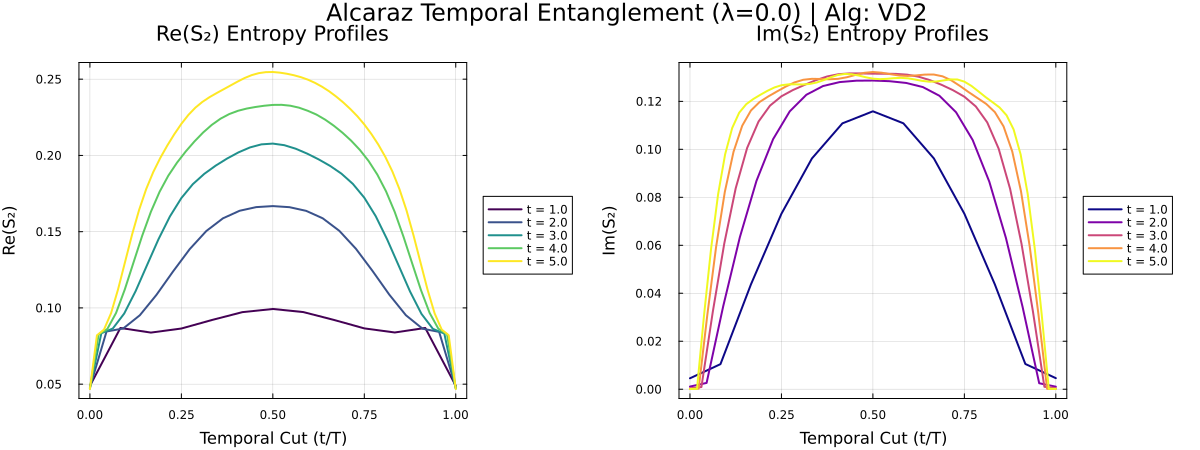

In [10]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.0,
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "VD2",
    alg = "RTM"
)

display(tricritical_plot)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=657|"S=1/2,Site") <-> (dim=2|id=657|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=904|"Link,l=1") <-> (dim=3|id=946|"Link,l=2"), normdiff = 0.944688073151956
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=913|"S=1/2,Site") <-> (dim=2|id=913|

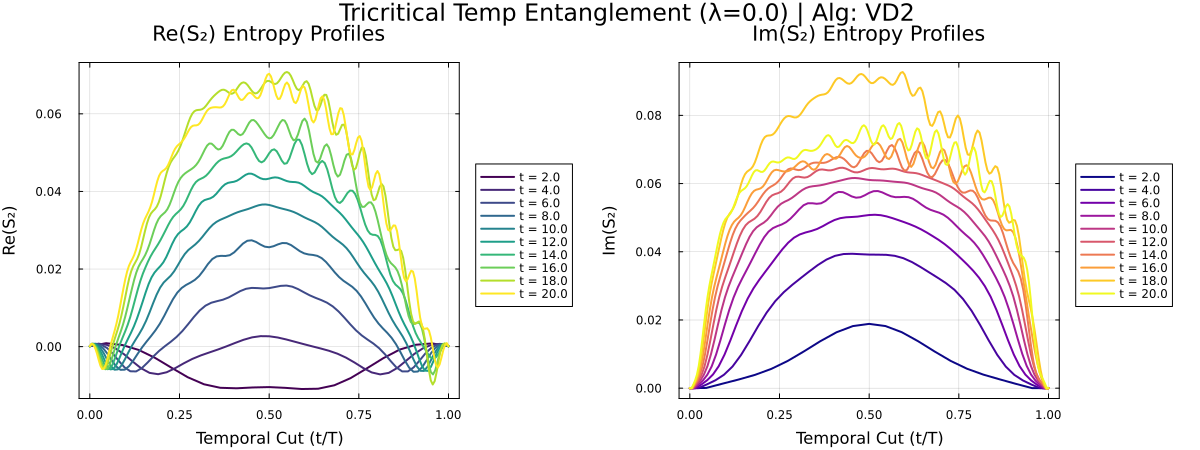

In [4]:
dense_times = collect(2.0 : 2.0 : 20.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.0,
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "VD2",
    alg = "RTM"
)

display(tricritical_plot)

In [ ]:
dense_times = collect(2.0 : 2.0 : 20.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.0,
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "WII",
    alg = "RTM"
)

display(tricritical_plot)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=309|"S=1/2,Site") <-> (dim=2|id=309|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=498|"Link,l=1") <-> (dim=3|id=296|"Link,l=2"), normdiff = 2.006530930196486
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=455|"S=1/2,Site") <-> (dim=2|id=455|

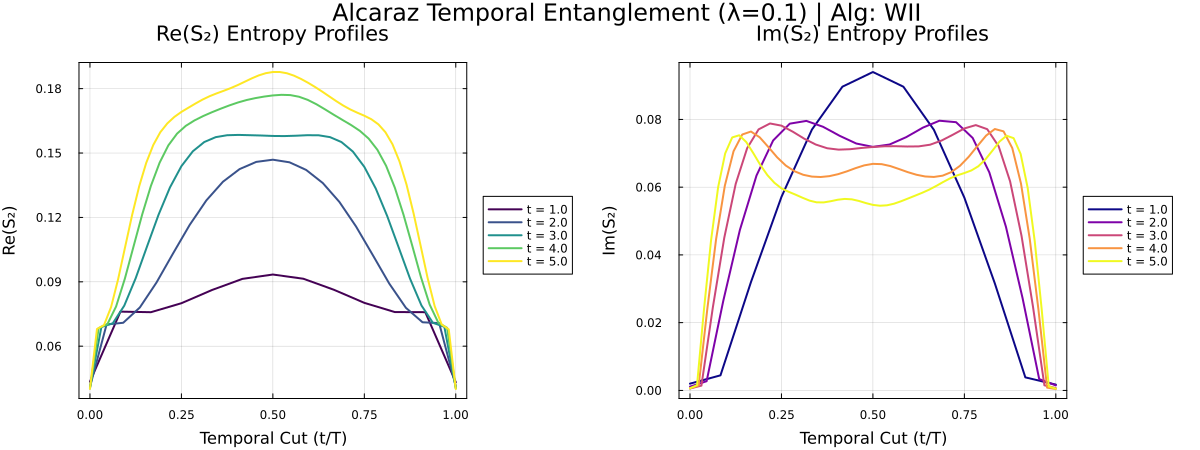

In [11]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.1,
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "WII",
    alg = "RTM"
)

display(tricritical_plot)

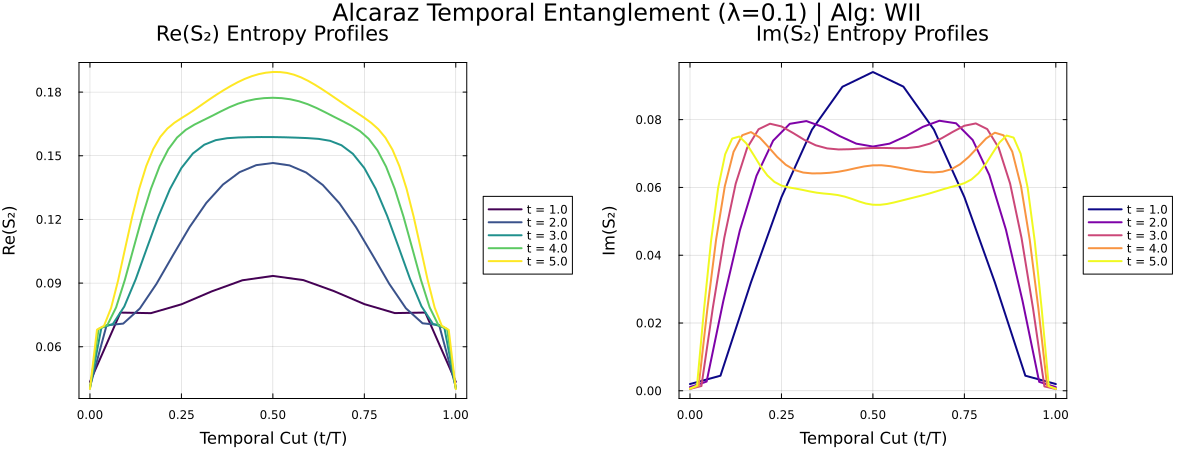

In [17]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.1,
    dt = 0.1,
    cutoff = 1e-15, 
    maxdim = 256,
    MPO_alg = "WII",
    alg = "RTM"
)

display(tricritical_plot)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=779|"S=1/2,Site") <-> (dim=2|id=779|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=941|"Link,l=1") <-> (dim=3|id=596|"Link,l=2"), normdiff = 1.907501077301492
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=543|"S=1/2,Site") <-> (dim=2|id=543|

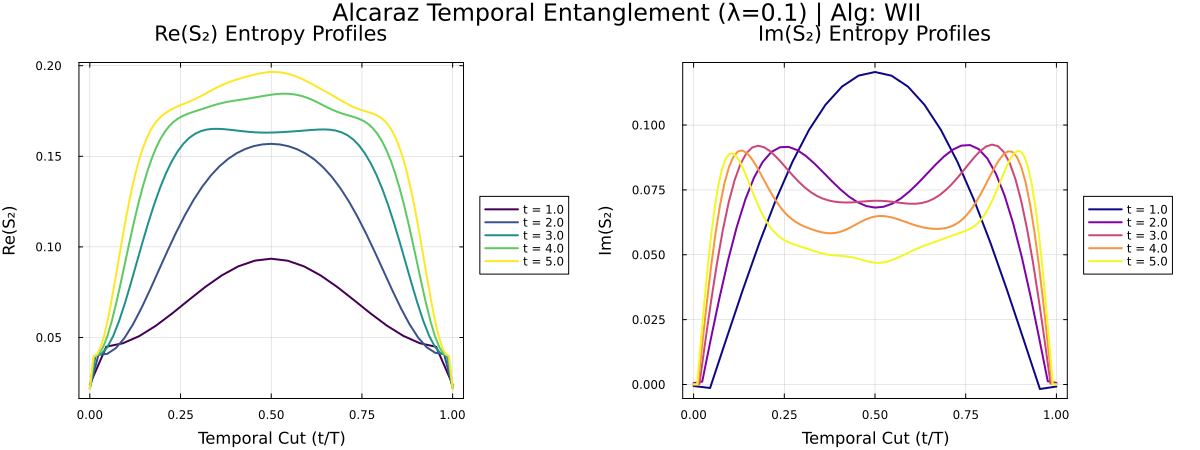

In [14]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.1,
    dt = 0.05,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "WII",
    alg = "RTM"
)

display(tricritical_plot)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=70|"S=1/2,Site") <-> (dim=2|id=70|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=849|"Link,l=1") <-> (dim=3|id=999|"Link,l=2"), normdiff = 2.006530930196486
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=969|"S=1/2,Site") <-> (dim=2|id=969|"S

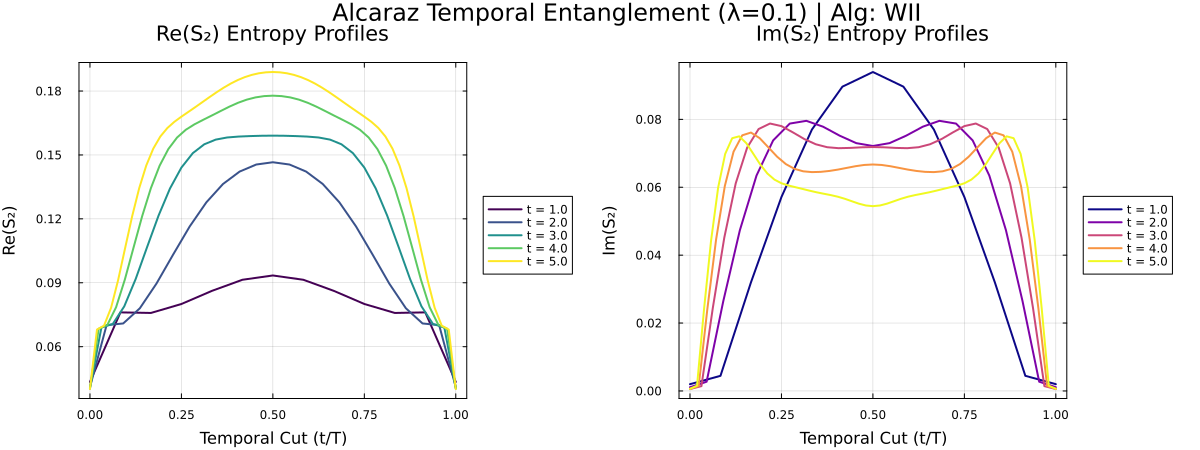

In [15]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.1,
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "WII",
    alg = "densitymatrix"
)

display(tricritical_plot)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=882|"S=1/2,Site") <-> (dim=2|id=882|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=7|id=170|"Link,l=1") <-> (dim=7|id=867|"Link,l=2"), normdiff = 3.149960254504054
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=157|"S=1/2,Site") <-> (dim=2|id=157|

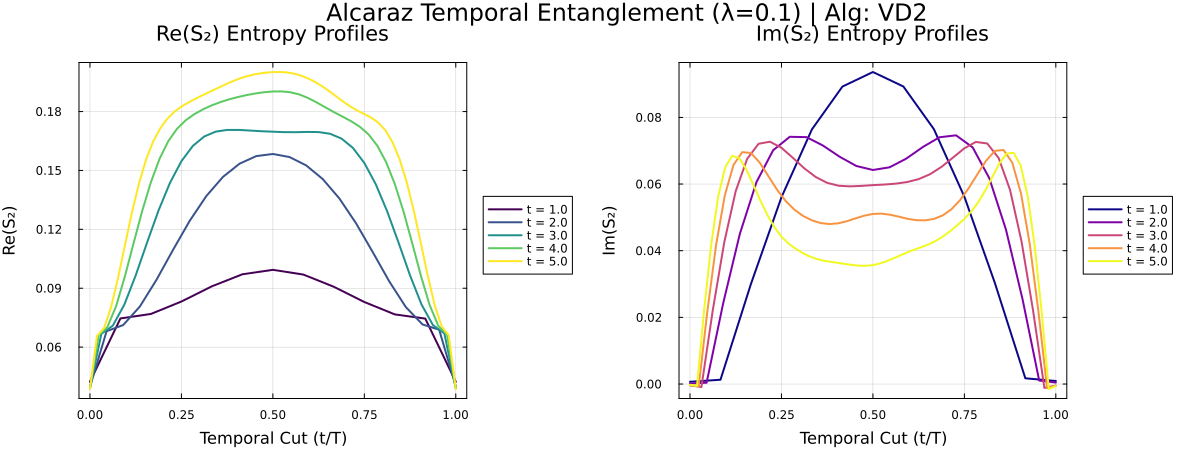

In [12]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.1,
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "VD2",
    alg = "RTM"
)

display(tricritical_plot)

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=221|"S=1/2,Site") <-> (dim=2|id=221|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=128|"Link,l=1") <-> (dim=3|id=636|"Link,l=2"), normdiff = 1.483982357550486
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=498|"S=1/2,Site") <-> (dim=2|id=498|

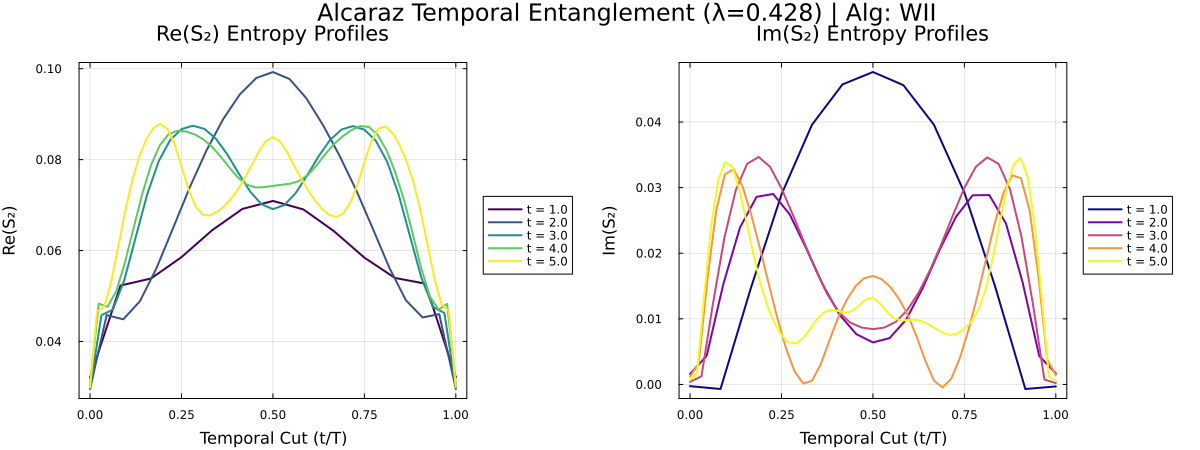

In [13]:
dense_times = collect(1.0 : 1.0 : 5.0) 

tricritical_plot = plot_entropy_profiles(
    expH_tricritical, 
    dense_times;
    lambda = 0.428, # Critical point from the paper
    dt = 0.1,
    cutoff = 1e-12, 
    maxdim = 256,
    MPO_alg = "WII",
    alg = "RTM"
)

display(tricritical_plot)

---

Let us consider now the ground state and see if it matches the CFT predictions

According to Conformal Field Theory (CFT), the von Neumann entropy for an open chain of length $L$ cut at subsystem size $l$ is given by

$$S(l) = \frac{c}{6} \ln \left( \frac{L}{\pi} \sin\left(\frac{l\pi}{L}\right) \right) + k$$

The maximum entanglement is always exactly in the middle of the chain, where $l = L/2$. If we plug $L/2$ into the sine function, $\sin(\pi/2) = 1$. Then the formula simplifies to:

$$S(L/2) = \frac{c}{6} \ln(L) + k'$$

Let us run DMRG for different system sizes ($L$), extract the entropy strictly at the middle bond, and plot it against $\ln(L)$. We should get a perfectly straight line with a slope of $c/6$.

Progress: 100%|█████████████████████████████████████████| Time: 0:04:09


Estimated Central Charge (c): 0.511


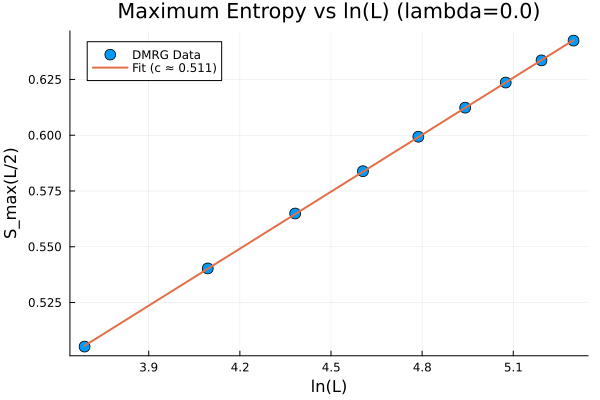

In [19]:
lambda = 0.0

N_values = [40, 60, 80, 100, 120, 140, 160, 180, 200]
max_entropies = Float64[]

sweeps = Sweeps(50)
maxdim!(sweeps, 10, 20, 100, 200, 400, 800, 800)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)


@showprogress for N in N_values
    sites = siteinds("Qubit", N)
    
    H_os = tricritical_opsum(N, lambda)
    H_mpo = MPO(H_os, sites)
    
    psi0 = randomMPS(sites, 10)
    energy, psi = dmrg(H_mpo, psi0, sweeps; outputlevel=0)
    
    # entropy at the exact middle of the chain (N/2)
    mid_bond = div(N, 2)
    orthogonalize!(psi, mid_bond)
    
    _, S, _ = svd(psi[mid_bond], (linkind(psi, mid_bond-1), siteind(psi, mid_bond)))
    
    SvN_mid = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 1e-12
            SvN_mid -= prob * log(prob)
        end
    end
    
    push!(max_entropies, SvN_mid)
end


# Our X axis is ln(N)
x_values = log.(N_values)
y_values = max_entropies

# Linear fit: S_max = (c/6) * ln(N) + k'
@. model(x, p) = p[1]*x + p[2]
p0 = [0.1, 1.0] 

fit = curve_fit(model, x_values, y_values, p0)

slope = fit.param[1]
c_est = slope * 6.0 


println("Estimated Central Charge (c): $(round(c_est, digits=3))")

# Ploting
fig = plot(title="Maximum Entropy vs ln(L) (lambda=$lambda)",
           xlabel="ln(L)",
           ylabel="S_max(L/2)",
           legend=:topleft,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data", markersize=6)

y_fit = model(x_values, fit.param)
plot!(fig, x_values, y_fit, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2)

display(fig)
# savefig(fig, "./imgs/cft_L.png")

Running DMRG...
After sweep 1 energy=-378.04751942035597  maxlinkdim=20 maxerr=1.14E-04 time=0.747
After sweep 2 energy=-380.3122208339915  maxlinkdim=78 maxerr=9.99E-13 time=5.118
After sweep 3 energy=-380.9531552654753  maxlinkdim=113 maxerr=9.99E-13 time=9.741
After sweep 4 energy=-381.2464701642301  maxlinkdim=96 maxerr=1.00E-12 time=9.043
After sweep 5 energy=-381.3910548454868  maxlinkdim=75 maxerr=9.98E-13 time=5.615
After sweep 6 energy=-381.47631913943684  maxlinkdim=60 maxerr=9.99E-13 time=3.636
After sweep 7 energy=-381.53875697437746  maxlinkdim=55 maxerr=1.00E-12 time=3.003
After sweep 8 energy=-381.566455181193  maxlinkdim=51 maxerr=9.99E-13 time=2.539
After sweep 9 energy=-381.58014658775494  maxlinkdim=46 maxerr=1.00E-12 time=2.073
After sweep 10 energy=-381.58952577942483  maxlinkdim=43 maxerr=1.00E-12 time=1.613
After sweep 11 energy=-381.59533637448385  maxlinkdim=42 maxerr=9.98E-13 time=2.003
After sweep 12 energy=-381.59964471992447  maxlinkdim=39 maxerr=1.00E-12 t

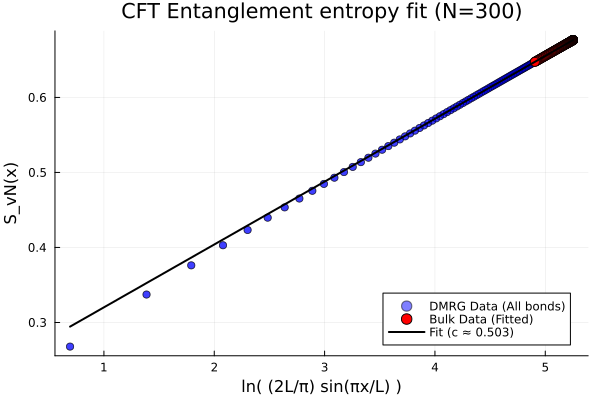

In [20]:
N = 300
lambda = 0.0

sites = siteinds("S=1/2", N)


H_os = tricritical_opsum(N, lambda)
H_mpo = MPO(H_os, sites)

# DMRG
sweeps = Sweeps(50)
maxdim!(sweeps, 20, 100, 200, 400, 800, 1000)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)

psi0 = randomMPS(sites, 10)
println("Running DMRG...")
energy, psi = dmrg(H_mpo, psi0, sweeps; outputlevel=1)

# Spatial Entanglement Sweep
entropies = Float64[]
bonds = collect(1:(N-1))

println("Calculating Entanglement Entropy across all spatial cuts...")
for b in bonds
    orthogonalize!(psi, b)
    
    # Handle the OBC edge case: no left link for the first site
    if b == 1
        left_inds = (siteind(psi, b),)
    else
        left_inds = (linkind(psi, b-1), siteind(psi, b))
    end
    
    _, S, _ = svd(psi[b], left_inds)
    
    SvN = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0.0
            SvN -= prob * log(prob)
        end
    end
    
    push!(entropies, SvN)
end

# Fit
chord_distances = @. (2 * N / pi) * sin(pi * bonds / N)
x_values = log.(chord_distances)
y_values = entropies


bulk_indices = findall(x -> (N/4 <= x <= 3N/4), bonds)
x_fit_data = x_values[bulk_indices]
y_fit_data = y_values[bulk_indices]

# Model: y = (c/6) * x + g -> param[1] is c, param[2] is g
@. model(x, p) = (p[1]/6.0) * x + p[2]
p0 = [0.5, 1.0] # Initial guess expecting c=0.5

fit = curve_fit(model, x_fit_data, y_fit_data, p0)
c_est = fit.param[1]

println("Estimated Central Charge (c): $(round(c_est, digits=4))")

fig = plot(title="CFT Entanglement entropy fit (N=$N)",
           xlabel="ln( (2L/π) sin(πx/L) )",
           ylabel="S_vN(x)",
           legend=:bottomright,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data (All bonds)", markersize=4, color=:blue, alpha=0.5)

scatter!(fig, x_fit_data, y_fit_data, label="Bulk Data (Fitted)", markersize=5, color=:red)

# Plot the ideal fit line extended across the graph
x_line = range(minimum(x_values), maximum(x_values), length=100)
y_line = model(x_line, fit.param)
plot!(fig, x_line, y_line, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2, color=:black)

display(fig)

Running DMRG...
After sweep 1 energy=-337.61245303331026  maxlinkdim=20 maxerr=1.61E-04 time=1.105
After sweep 2 energy=-339.63152787659357  maxlinkdim=100 maxerr=2.30E-12 time=12.105
After sweep 3 energy=-340.27884698392944  maxlinkdim=152 maxerr=1.00E-12 time=27.489
After sweep 4 energy=-340.5473179241544  maxlinkdim=117 maxerr=1.00E-12 time=27.218
After sweep 5 energy=-340.6567844389176  maxlinkdim=91 maxerr=1.00E-12 time=13.483
After sweep 6 energy=-340.7211842156552  maxlinkdim=79 maxerr=1.00E-12 time=8.733
After sweep 7 energy=-340.7510965673292  maxlinkdim=65 maxerr=1.00E-12 time=6.090
After sweep 8 energy=-340.76939791191165  maxlinkdim=59 maxerr=1.00E-12 time=5.426
After sweep 9 energy=-340.7829905208397  maxlinkdim=57 maxerr=9.99E-13 time=4.044
After sweep 10 energy=-340.7969908705567  maxlinkdim=58 maxerr=9.99E-13 time=4.583
After sweep 11 energy=-340.80825947440627  maxlinkdim=59 maxerr=1.00E-12 time=4.298
After sweep 12 energy=-340.8173715316065  maxlinkdim=62 maxerr=1.00E

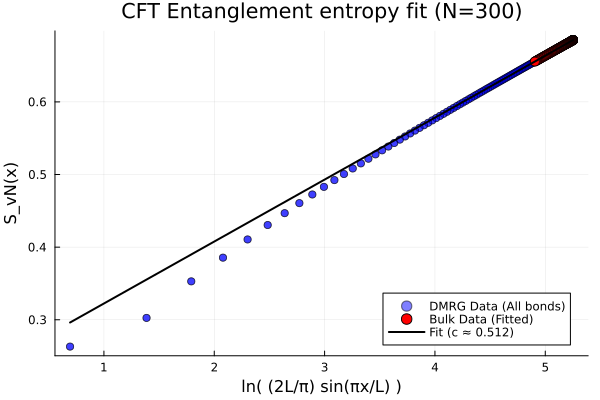

In [21]:
N = 300
lambda = 0.2

sites = siteinds("S=1/2", N)


H_os = tricritical_opsum(N, lambda)
H_mpo = MPO(H_os, sites)

# DMRG
sweeps = Sweeps(50)
maxdim!(sweeps, 20, 100, 200, 400, 800, 1000)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)

psi0 = randomMPS(sites, 10)
println("Running DMRG...")
energy, psi = dmrg(H_mpo, psi0, sweeps; outputlevel=1)

# Spatial Entanglement Sweep
entropies = Float64[]
bonds = collect(1:(N-1))

println("Calculating Entanglement Entropy across all spatial cuts...")
for b in bonds
    orthogonalize!(psi, b)
    
    # Handle the OBC edge case: no left link for the first site
    if b == 1
        left_inds = (siteind(psi, b),)
    else
        left_inds = (linkind(psi, b-1), siteind(psi, b))
    end
    
    _, S, _ = svd(psi[b], left_inds)
    
    SvN = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0.0
            SvN -= prob * log(prob)
        end
    end
    
    push!(entropies, SvN)
end

# Fit
chord_distances = @. (2 * N / pi) * sin(pi * bonds / N)
x_values = log.(chord_distances)
y_values = entropies


bulk_indices = findall(x -> (N/4 <= x <= 3N/4), bonds)
x_fit_data = x_values[bulk_indices]
y_fit_data = y_values[bulk_indices]

# Model: y = (c/6) * x + g -> param[1] is c, param[2] is g
@. model(x, p) = (p[1]/6.0) * x + p[2]
p0 = [0.5, 1.0] # Initial guess expecting c=0.5

fit = curve_fit(model, x_fit_data, y_fit_data, p0)
c_est = fit.param[1]

println("Estimated Central Charge (c): $(round(c_est, digits=4))")

fig = plot(title="CFT Entanglement entropy fit (N=$N)",
           xlabel="ln( (2L/π) sin(πx/L) )",
           ylabel="S_vN(x)",
           legend=:bottomright,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data (All bonds)", markersize=4, color=:blue, alpha=0.5)

scatter!(fig, x_fit_data, y_fit_data, label="Bulk Data (Fitted)", markersize=5, color=:red)

# Plot the ideal fit line extended across the graph
x_line = range(minimum(x_values), maximum(x_values), length=100)
y_line = model(x_line, fit.param)
plot!(fig, x_line, y_line, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2, color=:black)

display(fig)

Running DMRG...
After sweep 1 energy=-304.1959075403872  maxlinkdim=20 maxerr=4.66E-05 time=1.083
After sweep 2 energy=-305.92138354679724  maxlinkdim=100 maxerr=4.01E-11 time=12.786
After sweep 3 energy=-306.5295493232958  maxlinkdim=186 maxerr=9.99E-13 time=37.940
After sweep 4 energy=-306.78913263235285  maxlinkdim=136 maxerr=1.00E-12 time=37.636
After sweep 5 energy=-306.8891924758271  maxlinkdim=115 maxerr=1.00E-12 time=22.991
After sweep 6 energy=-306.942773274611  maxlinkdim=97 maxerr=1.00E-12 time=16.368
After sweep 7 energy=-306.98021387714  maxlinkdim=87 maxerr=1.00E-12 time=11.849
After sweep 8 energy=-307.0105675917026  maxlinkdim=90 maxerr=9.99E-13 time=9.674
After sweep 9 energy=-307.0305844622439  maxlinkdim=108 maxerr=9.99E-13 time=8.789
After sweep 10 energy=-307.0478325232918  maxlinkdim=111 maxerr=9.99E-13 time=8.034
After sweep 11 energy=-307.06413769406674  maxlinkdim=96 maxerr=1.00E-12 time=7.675
After sweep 12 energy=-307.0740956391528  maxlinkdim=93 maxerr=9.99E

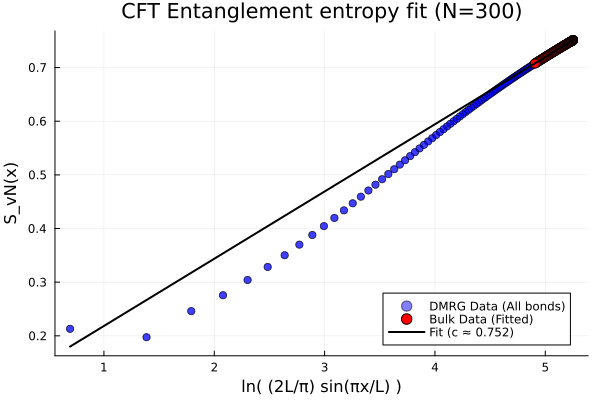

In [22]:
N = 300
lambda = 0.4

sites = siteinds("S=1/2", N)


H_os = tricritical_opsum(N, lambda)
H_mpo = MPO(H_os, sites)

# DMRG
sweeps = Sweeps(50)
maxdim!(sweeps, 20, 100, 200, 400, 800, 1000)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)

psi0 = randomMPS(sites, 10)
println("Running DMRG...")
energy, psi = dmrg(H_mpo, psi0, sweeps; outputlevel=1)

# Spatial Entanglement Sweep
entropies = Float64[]
bonds = collect(1:(N-1))

println("Calculating Entanglement Entropy across all spatial cuts...")
for b in bonds
    orthogonalize!(psi, b)
    
    # Handle the OBC edge case: no left link for the first site
    if b == 1
        left_inds = (siteind(psi, b),)
    else
        left_inds = (linkind(psi, b-1), siteind(psi, b))
    end
    
    _, S, _ = svd(psi[b], left_inds)
    
    SvN = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0.0
            SvN -= prob * log(prob)
        end
    end
    
    push!(entropies, SvN)
end

# Fit
chord_distances = @. (2 * N / pi) * sin(pi * bonds / N)
x_values = log.(chord_distances)
y_values = entropies


bulk_indices = findall(x -> (N/4 <= x <= 3N/4), bonds)
x_fit_data = x_values[bulk_indices]
y_fit_data = y_values[bulk_indices]

# Model: y = (c/6) * x + g -> param[1] is c, param[2] is g
@. model(x, p) = (p[1]/6.0) * x + p[2]
p0 = [0.5, 1.0] # Initial guess expecting c=0.5

fit = curve_fit(model, x_fit_data, y_fit_data, p0)
c_est = fit.param[1]

println("Estimated Central Charge (c): $(round(c_est, digits=4))")

fig = plot(title="CFT Entanglement entropy fit (N=$N)",
           xlabel="ln( (2L/π) sin(πx/L) )",
           ylabel="S_vN(x)",
           legend=:bottomright,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data (All bonds)", markersize=4, color=:blue, alpha=0.5)

scatter!(fig, x_fit_data, y_fit_data, label="Bulk Data (Fitted)", markersize=5, color=:red)

# Plot the ideal fit line extended across the graph
x_line = range(minimum(x_values), maximum(x_values), length=100)
y_line = model(x_line, fit.param)
plot!(fig, x_line, y_line, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2, color=:black)

display(fig)

Running DMRG...
After sweep 1 energy=-297.5411623914552  maxlinkdim=20 maxerr=3.74E-05 time=1.261
After sweep 2 energy=-299.414659099236  maxlinkdim=100 maxerr=1.94E-11 time=11.888
After sweep 3 energy=-300.0077495978599  maxlinkdim=198 maxerr=1.00E-12 time=30.909
After sweep 4 energy=-300.13620385653087  maxlinkdim=145 maxerr=9.99E-13 time=23.178
After sweep 5 energy=-300.13965793430333  maxlinkdim=67 maxerr=9.99E-13 time=6.406
After sweep 6 energy=-300.13981300176897  maxlinkdim=35 maxerr=9.99E-13 time=2.346
After sweep 7 energy=-300.13982552701134  maxlinkdim=23 maxerr=9.96E-13 time=1.100
After sweep 8 energy=-300.139826377827  maxlinkdim=22 maxerr=9.98E-13 time=0.417
After sweep 9 energy=-300.1398263887519  maxlinkdim=22 maxerr=8.56E-13 time=0.354
After sweep 10 energy=-300.13982638875154  maxlinkdim=22 maxerr=8.45E-13 time=0.298
After sweep 11 energy=-300.1398263887515  maxlinkdim=22 maxerr=8.45E-13 time=0.268
After sweep 12 energy=-300.139826388751  maxlinkdim=22 maxerr=8.45E-13 

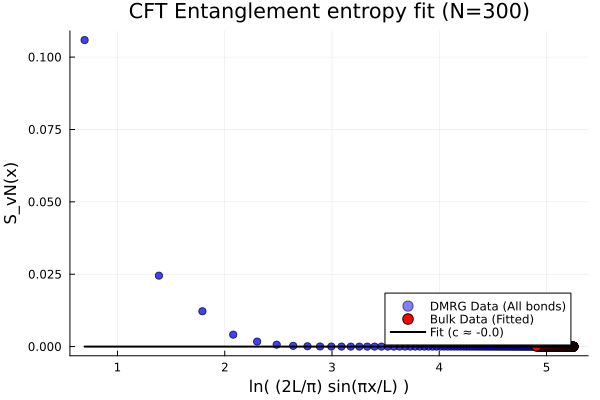

In [23]:
N = 300
lambda = 0.5

sites = siteinds("S=1/2", N)


H_os = tricritical_opsum(N, lambda)
H_mpo = MPO(H_os, sites)

# DMRG
sweeps = Sweeps(50)
maxdim!(sweeps, 20, 100, 200, 400, 800, 1000)
cutoff!(sweeps, 1e-12)
noise!(sweeps, 1e-4, 1e-5, 1e-6, 0.0)

psi0 = randomMPS(sites, 10)
println("Running DMRG...")
energy, psi = dmrg(H_mpo, psi0, sweeps; outputlevel=1)

# Spatial Entanglement Sweep
entropies = Float64[]
bonds = collect(1:(N-1))

println("Calculating Entanglement Entropy across all spatial cuts...")
for b in bonds
    orthogonalize!(psi, b)
    
    # Handle the OBC edge case: no left link for the first site
    if b == 1
        left_inds = (siteind(psi, b),)
    else
        left_inds = (linkind(psi, b-1), siteind(psi, b))
    end
    
    _, S, _ = svd(psi[b], left_inds)
    
    SvN = 0.0
    for n in 1:dim(S, 1)
        prob = S[n,n]^2
        if prob > 0.0
            SvN -= prob * log(prob)
        end
    end
    
    push!(entropies, SvN)
end

# Fit
chord_distances = @. (2 * N / pi) * sin(pi * bonds / N)
x_values = log.(chord_distances)
y_values = entropies


bulk_indices = findall(x -> (N/4 <= x <= 3N/4), bonds)
x_fit_data = x_values[bulk_indices]
y_fit_data = y_values[bulk_indices]

# Model: y = (c/6) * x + g -> param[1] is c, param[2] is g
@. model(x, p) = (p[1]/6.0) * x + p[2]
p0 = [0.5, 1.0] # Initial guess expecting c=0.5

fit = curve_fit(model, x_fit_data, y_fit_data, p0)
c_est = fit.param[1]

println("Estimated Central Charge (c): $(round(c_est, digits=4))")

fig = plot(title="CFT Entanglement entropy fit (N=$N)",
           xlabel="ln( (2L/π) sin(πx/L) )",
           ylabel="S_vN(x)",
           legend=:bottomright,
           grid=true)

scatter!(fig, x_values, y_values, label="DMRG Data (All bonds)", markersize=4, color=:blue, alpha=0.5)

scatter!(fig, x_fit_data, y_fit_data, label="Bulk Data (Fitted)", markersize=5, color=:red)

# Plot the ideal fit line extended across the graph
x_line = range(minimum(x_values), maximum(x_values), length=100)
y_line = model(x_line, fit.param)
plot!(fig, x_line, y_line, label="Fit (c ≈ $(round(c_est, digits=3)))", linewidth=2, color=:black)

display(fig)

The system remain critical until reaching $\lambda \approx 0.4$